In [1]:
from Q
import torch
import torch.nn as nn

In [2]:
sarsa = SemiGradSarsa()

In [3]:
N_qbits = 3
max_steps = 10
allowed_gates = "H X Z M CX"
env = QbitEnv(N_qbits, allowed_gates, max_steps, starting_aid=2)

In [4]:
class ActionModel(nn.Module):
    def __init__(self, max_steps, n_actions):
        super(ActionModel, self).__init__()
        feature_length = max_steps * 3 * n_actions
        self.w = nn.Linear(max_steps * n_actions * 3, n_actions, dtype=torch.float32, bias=False)
        self.start = nn.Parameter(torch.zeros(n_actions, dtype=torch.float32, requires_grad=True))

    def forward(self, S):
        if not isinstance(S, torch.Tensor):
            out = torch.tensor(S)
        else:
            out = S.clone().detach()
        if torch.all(out == 0.):
            return self.start
        else:
            return self.w(out)


In [5]:
net = ActionModel(max_steps, n_actions=env.get_action_length())

In [6]:
sarsa.setting(eps=0.1, alpha=0.1, gamma=0.9)

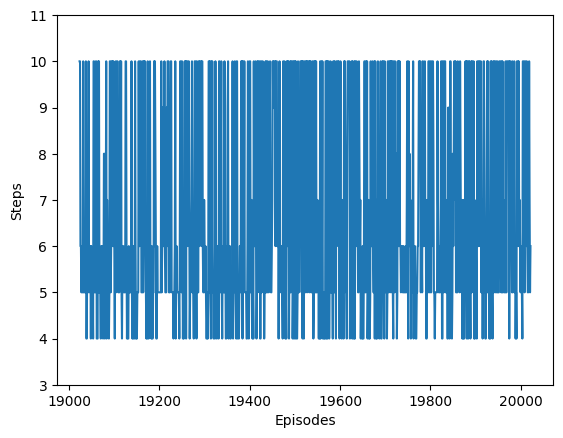

In [18]:
wins = sarsa.run(env, net, max_episode=10000, max_steps=max_steps, catch_wins=True, plot_range=[3,11])

In [6]:
env.test_net(net)

C[2]->X[1]
H->[2]
M->[2]	m = 0
M->[1]	m = 1
X->[0]

Goal in 5 steps!
